<a href="https://colab.research.google.com/github/cahyoadi88/Script/blob/main/Copy_of_04_20230313_Cluster_Sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 align=center><font size = 3> Asistensi Pertemuan 4 - Week 4</font></h1>
<h1 align=center><font size = 5>$\text{Single Stage Cluster Sampling}$</font></h1>

In [ ]:
# Load data manipulation package
import numpy as np
import pandas as pd

# Load statistic package
from scipy import stats

# Load random package
import random

# Load data visualization package
import matplotlib.pyplot as plt
import seaborn as sns

# <font color='blue'>Student Performance</font>
---

- Seorang peneliti ingin melakukan studi untuk menilai hasil belajar siswa SMA di tahun kedua di suatu negara dengan total 234 kabupaten. 
- Tidak mungkin melakukan studi penelitian yang melibatkan siswa di setiap SMA.


- Akan diobservasi dengan ketentuan :
    - Sampel diambil dari **15 kabupaten**
    - Setiap kabupaten **unequal size** 

In [ ]:
# Load the data
kode_kab = [101, 98, 67, 60, 33, 56, 134, 105, 22, 2, 76, 8, 1, 94, 37]
jum_siswa = [890, 734, 751, 809, 823, 869, 692, 604, 757, 800, 878, 837, 950, 726, 832]
avg_kab = [66, 77, 68, 86, 75, 65, 78, 77, 75, 80, 74, 79, 86, 70, 75]

df_sample_data = pd.DataFrame({"kode kab." : kode_kab,
                                "jumlah siswa" : jum_siswa,
                                "rata-rata" : avg_kab,
                               })

df_sample_data

,kode kab.,jumlah siswa,rata-rata
0,101,890,66
1,98,734,77
2,67,751,68
3,60,809,86
4,33,823,75
5,56,869,65
6,134,692,78
7,105,604,77
8,22,757,75
9,2,800,80


In [ ]:
# Summary variables
N = 234                           # jumlah total kabupaten = 234
n = len(df_sample_data)           # jumlah sampel kabupaten

print(f"jumlah total kabupaten     : {N}")
print(f"jumlah sampel kabupaten    : {n}")

jumlah total kabupaten     : 234
jumlah sampel kabupaten    : 15


## **1. Estimate Parameter Rata-rata**

- Estimasi rata-rata penilaian hasil belajar siswa $\hat{\mu}_{r}$

$$
\hat{\mu}_{r} = r = \cfrac{\sum_{i=1}^{n} y_{i}}{\sum_{i=1}^{n} M_{i}}
$$

In [ ]:
# y_i merupakan total nilai dari setiap kabupaten
y_total = np.sum(df_sample_data["jumlah siswa"] * df_sample_data["rata-rata"])

# M_i merupakan jumlah siswa di masing-masing kabupaten
M = np.sum(df_sample_data["jumlah siswa"])

# r or mu_r merupakan hasil belajar 
mu_r = y_total / M

print(f"Total hasil belajar                   : {y_total}")
print(f"Total siswa yang menjadi sampel       : {M}")
print(f"Rata-rata hasil belajar               : {mu_r:.3f}")

Total hasil belajar                   : 901384
Total siswa yang menjadi sampel       : 11952
Rata-rata hasil belajar               : 75.417


## **2. Estimate the estimator 95% CI**

- with the sampled cluster variance ($s_{c}^{2}$) 

$$
s_{c}^{2} = \cfrac{1}{n-1} \sum_{i=1}^{n} (y_{i} - rM_{i})^{2}
$$

In [ ]:
# sampled cluster variance
# Note that r = mu_r, hence
sc_square = np.sum(((df_sample_data["jumlah siswa"] * df_sample_data["rata-rata"]) - (mu_r*df_sample_data["jumlah siswa"]))**2) / (n-1)
print(f"The sampled cluster variance        : ({np.sqrt(sc_square):.3f})^2")

The sampled cluster variance        : (5364.199)^2


- Then we have to find the variance of total population estimator, $\widehat{\text{var}}(\hat{\tau}_{r})$, by using this equation

$$
\widehat{\text{var}}(\hat{\tau}_{r}) = N(N-n) \cfrac{s_{c}^{2}}{n}
$$

In [ ]:
# Next we calculate the variance of total population estimator
var_y_total_est = N*(N-n)*(sc_square/n)
print(f"The variance of total pop. est.     : ({np.sqrt(var_y_total_est):.3f})^2")

The variance of total pop. est.     : (313537.326)^2


-The variance of mean ssu estimator ($\widehat{\text{var}}(\hat{\mu}_{r})$), hence we can obtain it by solving this equation.

$$
\widehat{\text{var}}(\hat{\mu}_{r}) = \cfrac{1}{(N\bar{M})^{2}} \widehat{\text{var}}(\hat{\tau}_{r})
$$

In [ ]:
# Find the mean of students from the sampled
M_bar = np.mean(df_sample_data["jumlah siswa"])
print(f"Rata-rata jumlah sampel siswa        : {M_bar:.0f}")

Rata-rata jumlah sampel siswa        : 797


In [ ]:
# Calculate the variance of mean ssu estimator
var_y_mean_est = var_y_total_est / ((N*M_bar)**2)
print(f"The variance of mean ssu. est.                  : ({np.sqrt(var_y_mean_est):.3f})^2")

The variance of mean ssu. est.                  : (1.682)^2


- The 95% CI can be calculated from

$$
95 \% \text{CI} = \hat{\mu}_{r} \pm d
$$

- with Margin of error ($d$)
$$
d = z_{\alpha/2} \sqrt{\widehat{\text{var}}(\hat{\mu}_{r})}
$$

In [ ]:
# calculate z_stat @ 95% CI
alpha = 0.05
z_stat = stats.norm.ppf(1 - alpha/2)
print(f"z_stat              : {z_stat:.2f}")

# calculate the margin of error (d)
d = z_stat * np.sqrt(var_y_mean_est)
print(f"margin of error (d) : {d:.3f}")

z_stat              : 1.96
margin of error (d) : 3.296


In [ ]:
# Calculate the CI
lb = mu_r + d
ub = mu_r - d

print(f"Selang kepercayaan 95% rata-rata hasil belajar siswa adalah {lb:.3f} sampai {ub:.3f}")

Selang kepercayaan 95% rata-rata hasil belajar siswa adalah 78.713 sampai 72.121


---
# $\text{Feedback Asistensi}$
Terima Kasih telah mengikuti sesi asistensi hari ini!

Jangan lupa untuk mengisi feedback juga yaa, link feedback dapat diakses di  https://bit.ly/FeedbackAsistensiSDA-Feb23

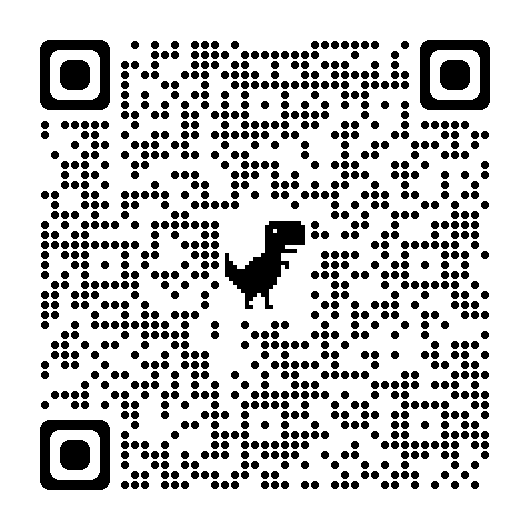

- Kelas = Sampling
- Teaching Assistant = Layli Rahmania Yuwono